<a href="https://colab.research.google.com/github/SonnayilaTejaswini/parallel_caption_generator/blob/main/Parallel_caption_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers==4.36.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the follow

In [ ]:
from transformers import pipeline
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import os
from multiprocessing import Pool, cpu_count

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [ ]:
captioner = pipeline("image-to-text", model="nlpconnect/vit-gpt2-image-captioning")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
/usr/local/lib/python3.12/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Parallel1.jpg to Parallel1.jpg
Saving parallel2.jpg to parallel2.jpg
Saving parallel3.jpg to parallel3.jpg
Saving parallel4.jpg to parallel4.jpg
Saving parallel5.jpg to parallel5.jpg
Saving parallel6.jpg to parallel6.jpg
Saving parallel7.jpg to parallel7.jpg
Saving parallel8.jpg to parallel8.jpg
Saving parallel9.webp to parallel9.webp
Saving parallel10.jpg to parallel10.jpg


In [ ]:
uploaded.keys()

dict_keys(['Parallel1.jpg', 'parallel2.jpg', 'parallel3.jpg', 'parallel4.jpg', 'parallel5.jpg', 'parallel6.jpg', 'parallel7.jpg', 'parallel8.jpg', 'parallel9.webp', 'parallel10.jpg'])

In [ ]:
def generate_caption(image_path):
    image = Image.open(image_path)
    result = captioner(image)
    caption = result[0]['generated_text']
    return caption

In [ ]:
print(generate_caption(list(uploaded.keys())[0]))

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1355: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


a man in a suit and tie is holding a camera 


In [ ]:
def generate_caption(image_path):
    image = Image.open(image_path)
    result = captioner(image, max_new_tokens=30)
    caption = result[0]['generated_text']
    return caption

In [ ]:
def create_meme(image_path, caption):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    width, height = image.size

    try:
        font = ImageFont.truetype("arial.ttf", 40)
    except:
        font = ImageFont.load_default()

    # Add background rectangle for visibility
    text_position = (10, height - 60)
    draw.rectangle([text_position, (width, height)], fill="black")

    # Add caption text
    draw.text(text_position, caption, fill="white", font=font)

    output_path = "meme_" + os.path.basename(image_path)
    image.save(output_path)

    return output_path

In [ ]:
def process_image(image_path):
    caption = generate_caption(image_path)
    meme = create_meme(image_path, caption)
    return meme

In [ ]:
image_paths = list(uploaded.keys())

with Pool(cpu_count()) as p:
    results = p.map(process_image, image_paths)

In [ ]:
results

['meme_Parallel1.jpg',
 'meme_parallel2.jpg',
 'meme_parallel3.jpg',
 'meme_parallel4.jpg',
 'meme_parallel5.jpg',
 'meme_parallel6.jpg',
 'meme_parallel7.jpg',
 'meme_parallel8.jpg',
 'meme_parallel9.webp',
 'meme_parallel10.jpg']

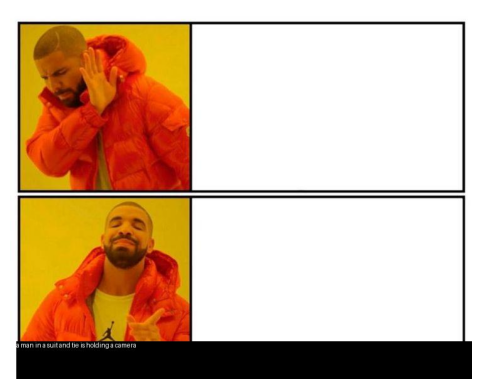

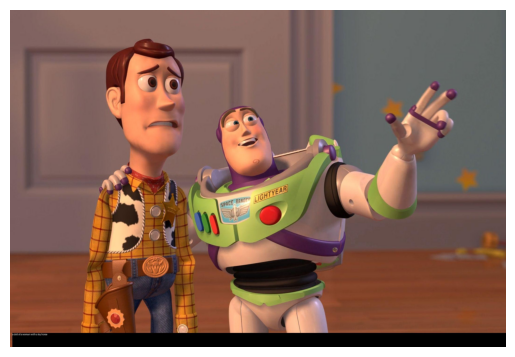

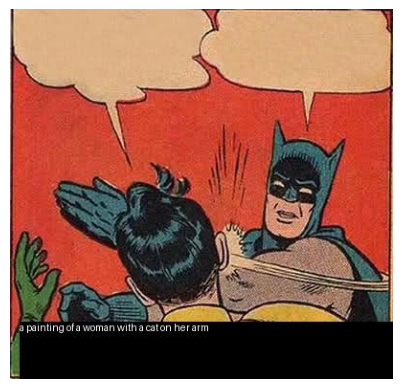

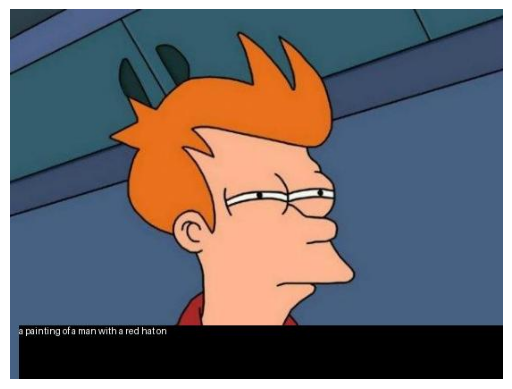

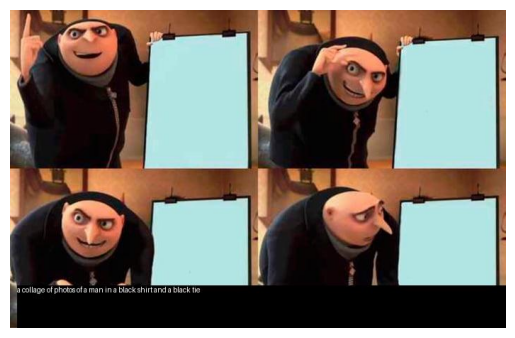

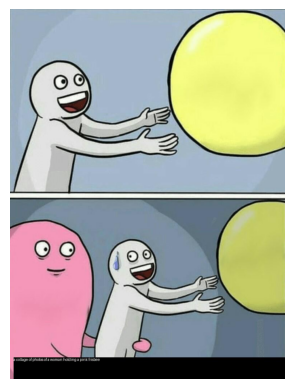

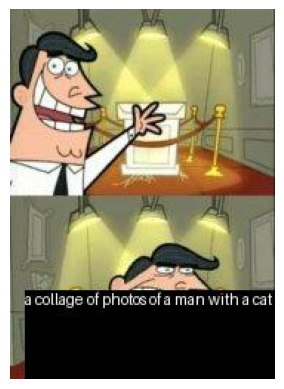

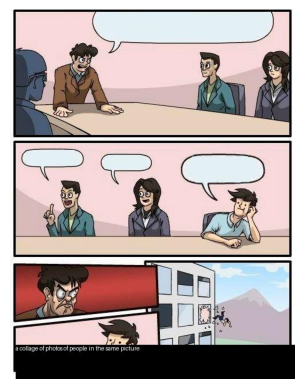

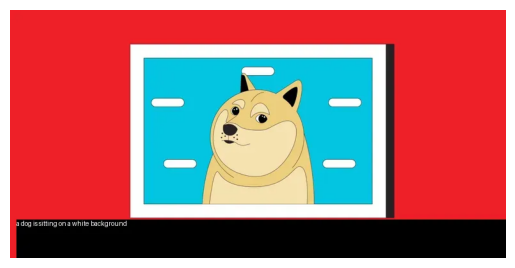

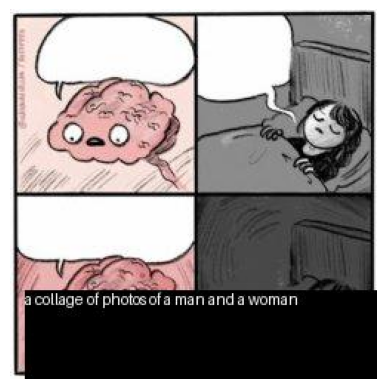

In [ ]:
for img_path in results:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [ ]:
import time

# Sequential
start = time.time()
for img in image_paths:
    process_image(img)
end = time.time()
print("Sequential Time:", end - start)

# Parallel
start = time.time()
with Pool(cpu_count()) as p:
    p.map(process_image, image_paths)
end = time.time()
print("Parallel Time:", end - start)

Sequential Time: 35.696436405181885
Parallel Time: 29.319164991378784


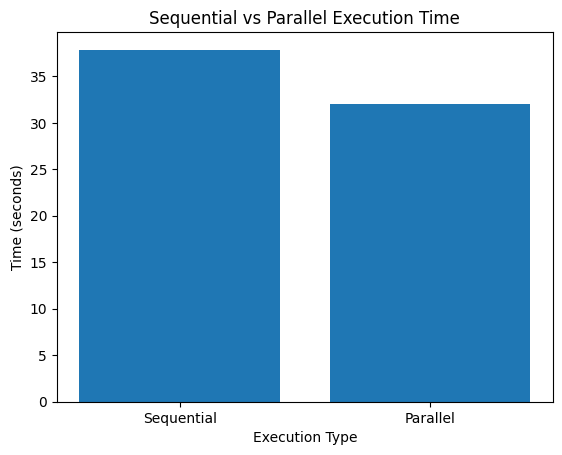

In [ ]:
import matplotlib.pyplot as plt

# Your actual values
labels = ["Sequential", "Parallel"]
times = [37.86, 32.07]

plt.figure()
plt.bar(labels, times)

plt.xlabel("Execution Type")
plt.ylabel("Time (seconds)")
plt.title("Sequential vs Parallel Execution Time")

plt.show()

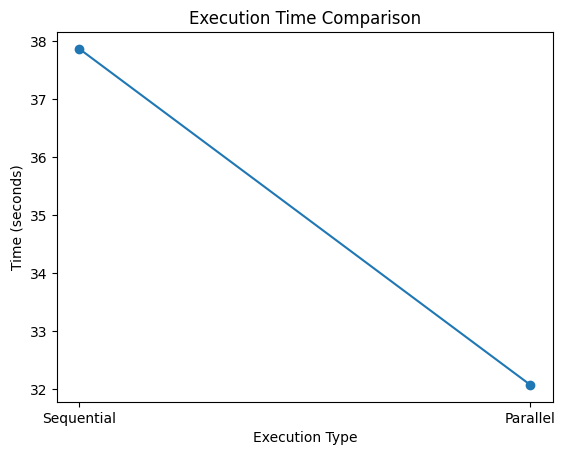

In [ ]:
import matplotlib.pyplot as plt

labels = ["Sequential", "Parallel"]
times = [37.86, 32.07]

plt.figure()
plt.plot(labels, times, marker='o')

plt.xlabel("Execution Type")
plt.ylabel("Time (seconds)")
plt.title("Execution Time Comparison")

plt.show()

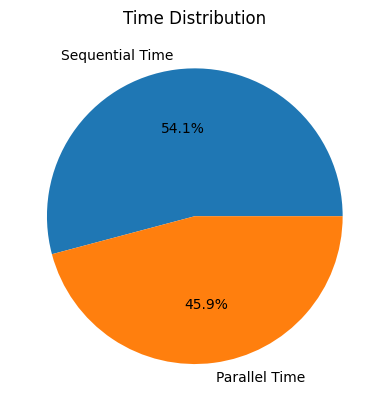

In [ ]:
import matplotlib.pyplot as plt

labels = ["Sequential Time", "Parallel Time"]
times = [37.86, 32.07]

plt.figure()
plt.pie(times, labels=labels, autopct='%1.1f%%')

plt.title("Time Distribution")

plt.show()